In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import joblib
import pandas as pd
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix

np.random.seed(42)

In [3]:
# Läs in träningsfilen
df = pd.read_csv(r"C:\Users\Eier\OneDrive\Dokument\DataScience\Data_science_projektkurs\archive (1)\diabetes_prediction_dataset.csv")
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df['gender'].unique())
print(df['smoking_history'].unique())
df_encoded = pd.get_dummies(df, columns=['gender', 'smoking_history'], drop_first=False)
print(df_encoded.head())
print(df_encoded.columns.tolist())
numeric_cols = ['age', 'hypertension', 'heart_disease', 'bmi', 
                'HbA1c_level', 'blood_glucose_level', 'diabetes']

df_numeric = df_encoded[numeric_cols]
print(df_numeric.describe().T)
print(df['diabetes'].value_counts())

Y = df_encoded['diabetes']
X = df_encoded.drop(columns=['diabetes'])

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB
None
                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min   

In [4]:
from sklearn.model_selection import train_test_split

# 70% train, 30% temp
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size=0.30, random_state=42, stratify=Y
)

# 15% val, 15% test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.50, random_state=42, stratify=Y_temp
)

print(X_train.shape, Y_train.shape)
print(X_val.shape, Y_val.shape)
print(X_test.shape, Y_test.shape)


(70000, 15) (70000,)
(15000, 15) (15000,)
(15000, 15) (15000,)


In [6]:
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=500,
        class_weight='balanced'
    ))
])

log_reg_baseline = log_reg.fit(X_train, Y_train)
score = log_reg_baseline.score(X_val, Y_val)

joblib.dump(log_reg, 'log_reg_trained.pkl')

print('Modellen är tränad och sparad.')
print("LogisticRegression (balanced):", score)

Modellen är tränad och sparad.
LogisticRegression (balanced): 0.8894


In [7]:
# Ladda modellen
log_reg_pipeline = joblib.load('log_reg_trained.pkl')

# Prediktioner
y_pred = log_reg_pipeline.predict(X_test)

# Rapport
print("Classification Report för LogisticRegression")
print(classification_report(Y_test, y_pred))

Classification Report för LogisticRegression
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     13725
           1       0.42      0.88      0.57      1275

    accuracy                           0.89     15000
   macro avg       0.71      0.88      0.75     15000
weighted avg       0.94      0.89      0.90     15000



In [8]:
# Ladda den tränade modellen
log_reg = joblib.load('log_reg_trained.pkl') 

# Gör prediktioner på valideringsdata med modellen
Y_val_pred = log_reg.predict(X_val)

# Utvärdera modellens prestanda
accuracy = accuracy_score(Y_val, Y_val_pred)
precision = precision_score(Y_val, Y_val_pred, average='macro')
recall = recall_score(Y_val, Y_val_pred, average='macro')
f1 = f1_score(Y_val, Y_val_pred, average='weighted')

# Samla resultaten
log_reg_results = [{
    'Model': 'LogisticRegression',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
}]

# Spara resultaten
joblib.dump(log_reg_results, 'log_reg_results.pkl')

# Konvertera listan till en DataFrame och visa resultaten
log_reg_results = pd.DataFrame(log_reg_results)
log_reg_results

,Model,Accuracy,Precision,Recall,F1-score
0,LogisticRegression,0.8894,0.707824,0.887982,0.905815


In [9]:
# Ladda den sparade modellen
log_reg = joblib.load('log_reg_trained.pkl')

# Definiera scorer
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# Beräkna cross-validation scores
cv_results = cross_validate(log_reg, X_train, Y_train, cv=5, scoring=scoring)

# Skapa en lista med resultaten
log_reg_results = []
for fold in range(5):
    log_reg_results.append({
        'Fold': fold,
        'Accuracy': cv_results['test_accuracy'][fold],
        'Precision': cv_results['test_precision'][fold],
        'Recall': cv_results['test_recall'][fold],
        'F1-score': cv_results['test_f1'][fold]
    })

# Konvertera listan till en DataFrame
log_reg_results = pd.DataFrame(log_reg_results)

# Spara DataFrame med joblib
joblib.dump(log_reg_results, 'cross_validation_results.pkl')

# Visa DataFrame
log_reg_results

,Fold,Accuracy,Precision,Recall,F1-score
0,0,0.888357,0.706366,0.886396,0.754766
1,1,0.885286,0.702644,0.884337,0.750385
2,2,0.887214,0.703439,0.877768,0.750753
3,3,0.889286,0.707565,0.887285,0.756184
4,4,0.883571,0.700738,0.883781,0.748149


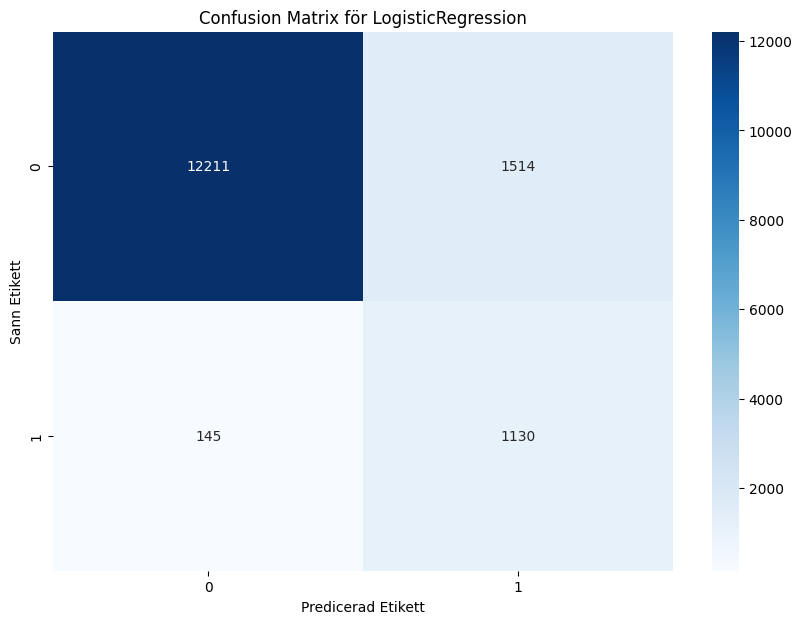

In [11]:
# Ladda tränade Logistiska regression modellen
log_reg = joblib.load('log_reg_trained.pkl')

# Gör prediktioner på testdata
Y_val_pred = log_reg.predict(X_val)

# Skapa Confusion Matrix
cm = confusion_matrix(Y_val, Y_val_pred)

# Visualisera Confusion Matrix som en heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(Y_test), yticklabels=np.unique(Y_test))
plt.title('Confusion Matrix för LogisticRegression')
plt.xlabel('Predicerad Etikett')
plt.ylabel('Sann Etikett')
plt.show()